In [1]:
from google.colab import files
files.upload()  # Choose kaggle.json from your Desktop

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"keshrivishal21","key":"4c8bb86460f4dd386e694fd83bc26447"}'}

In [2]:
!mkdir -p ~/.config/kaggle
!mv kaggle.json ~/.config/kaggle/kaggle.json
!chmod 600 ~/.config/kaggle/kaggle.json
print("Kaggle configured!")

Kaggle configured!


In [3]:
!kaggle competitions download -c state-farm-distracted-driver-detection

100% 3.99G/4.00G [00:38<00:00, 281MB/s]
100% 4.00G/4.00G [00:38<00:00, 112MB/s]


In [4]:
!unzip -q state-farm-distracted-driver-detection.zip -d data

In [5]:
import os

print(os.listdir("/content/data/imgs/train"))

['c0', 'c3', 'c9', 'c1', 'c2', 'c6', 'c8', 'c7', 'c4', 'c5']


In [6]:
import shutil
import random
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from keras.layers import Dense
import matplotlib.pyplot as plt

In [7]:
# paths
SOURCE_TRAIN_DIR = "/content/data/imgs/train"
PROCESSED_DIR = "/content/data/processed"

CLASS_NAMES = ["c0","c1","c2","c3","c4","c5","c6","c7","c8","c9"]

TRAIN_RATIO = 0.6
VAL_RATIO = 0.2
TEST_RATIO = 0.2

RANDOM_SEED = 42

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16

In [8]:
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

for split in ["train", "val", "test"]:
    for cls in CLASS_NAMES:
        create_dir(os.path.join(PROCESSED_DIR, split, cls))

In [9]:
# data split
random.seed(RANDOM_SEED)

for cls in CLASS_NAMES:
    cls_path = os.path.join(SOURCE_TRAIN_DIR, cls)
    images = [img for img in os.listdir(cls_path) if img.endswith(".jpg")]

    random.shuffle(images)

    total = len(images)
    train_end = int(total * TRAIN_RATIO)
    val_end   = int(total * (TRAIN_RATIO + VAL_RATIO))

    train_imgs = images[:train_end]
    val_imgs   = images[train_end:val_end]
    test_imgs  = images[val_end:]

    for img in train_imgs:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(PROCESSED_DIR, "train", cls, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(PROCESSED_DIR, "val", cls, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(PROCESSED_DIR, "test", cls, img)
        )

    print(f"{cls}: {len(train_imgs)} train | {len(val_imgs)} val | {len(test_imgs)} test")

c0: 1493 train | 498 val | 498 test
c1: 1360 train | 453 val | 454 test
c2: 1390 train | 463 val | 464 test
c3: 1407 train | 469 val | 470 test
c4: 1395 train | 465 val | 466 test
c5: 1387 train | 462 val | 463 test
c6: 1395 train | 465 val | 465 test
c7: 1201 train | 400 val | 401 test
c8: 1146 train | 382 val | 383 test
c9: 1277 train | 426 val | 426 test


In [10]:
def count_images(split):
    total = 0
    for cls in CLASS_NAMES:
        total += len(os.listdir(os.path.join(PROCESSED_DIR, split, cls)))
    return total

print("Train images:", count_images("train"))
print("Val images:", count_images("val"))
print("Test images:", count_images("test"))

Train images: 13451
Val images: 4483
Test images: 4490


In [11]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_DIR + "/train",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_DIR + "/val",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_DIR + "/test",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

Found 13451 files belonging to 10 classes.
Found 4483 files belonging to 10 classes.
Found 4490 files belonging to 10 classes.


In [12]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (16, 224, 224, 3)
Labels shape: (16, 10)


In [13]:
def original_model_mod6(input_shape=(224,224,3),num_classes=10):
  inputs = layers.Input(shape=input_shape)

  # Normalization
  x = layers.Rescaling(1./255)(inputs)

  # Block 1
  x = layers.Conv2D(16, (7, 7), padding="same", activation="relu")(x)
  x = layers.Conv2D(16, (7, 7), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # Block 2
  x = layers.Conv2D(32, (5, 5), padding="same", activation="relu")(x)
  x = layers.Conv2D(32, (5, 5), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # Bloack 3
  x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
  x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # Block 4
  x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
  x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # conv 9
  x = layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)


  x = layers.Flatten()(x)
  outputs = layers.Dense(10, activation="softmax")(x)

  model = models.Model(inputs, outputs, name="Original_CNN_mod6")
  return model


In [14]:
model1f = original_model_mod6()
model1f.summary()

Model: "Original_CNN_mod6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 16)   │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 112, 112, 16)   │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 32)   │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 56, 56, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 28, 28, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 14, 14, 128)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       501,770 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,127,194 (4.30 MB)

 Trainable params: 1,127,194 (4.30 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model1f.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mod6 = model1f.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200
)

Epoch 1/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 89s 89ms/step - accuracy: 0.5134 - loss: 1.3647 - val_accuracy: 0.9547 - val_loss: 0.1619
Epoch 2/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 52s 61ms/step - accuracy: 0.9727 - loss: 0.0991 - val_accuracy: 0.9824 - val_loss: 0.0728
Epoch 3/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 85s 65ms/step - accuracy: 0.9821 - loss: 0.0610 - val_accuracy: 0.9877 - val_loss: 0.0553
Epoch 4/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 79s 62ms/step - accuracy: 0.9918 - loss: 0.0307 - val_accuracy: 0.9855 - val_loss: 0.0529
Epoch 5/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 54s 64ms/step - accuracy: 0.9924 - loss: 0.0274 - val_accuracy: 0.9777 - val_loss: 0.0860
Epoch 6/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 51s 61ms/step - accuracy: 0.9914 - loss: 0.0251 - val_accuracy: 0.9935 - val_loss: 0.0308
Epoch 7/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 52s 62ms/step - accuracy: 0.9975 - loss: 0.0107 - val_accuracy: 0.9853 - val_loss: 0.0639
Epoch 8/200
841/841 ━━━━━━━━━━━━━━━━━━━━ 54s 64ms/step - accuracy: 0.9939 - loss: 0

In [ ]:
model1f.save("/content/data/models/original_cnn_mod6.keras")

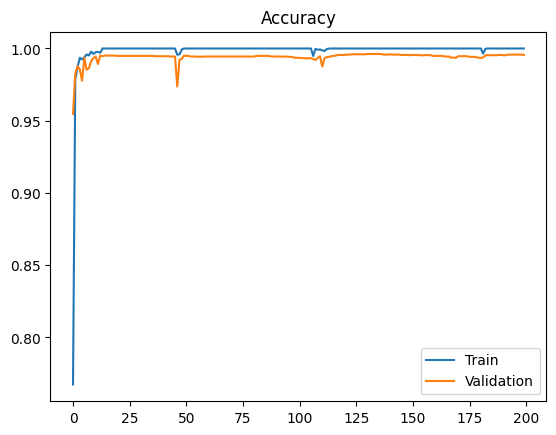

In [ ]:
# Accuracy curve
plt.plot(history_mod6.history['accuracy'])
plt.plot(history_mod6.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

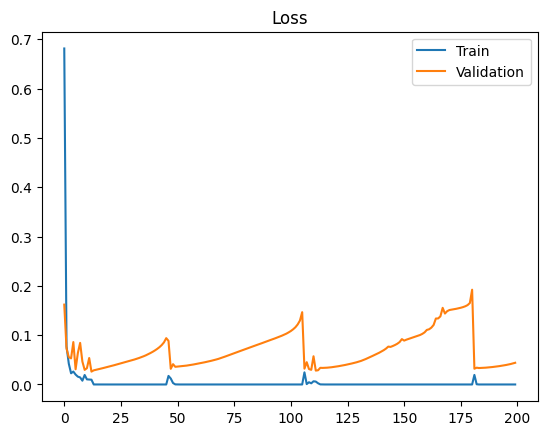

In [ ]:
# Loss curve
plt.plot(history_mod6.history['loss'])
plt.plot(history_mod6.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()

In [ ]:
test_loss, test_acc = model1f.evaluate(test_ds)
print("Test Accuracy:", test_acc)

281/281 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9940 - loss: 0.0673
Test Accuracy: 0.993318498134613


In [ ]:
import time
import numpy as np

sample_batch = next(iter(test_ds))[0]

start = time.time()
pred = model1f.predict(sample_batch)
end = time.time()

time_per_image = (end - start) / len(sample_batch)
print("Time per image (seconds):", time_per_image)
time_per_image = time_per_image * 1000
print("Time per image (milliseconds):", time_per_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step
Time per image (seconds): 0.044905900955200195
Time per image (milliseconds): 44.905900955200195
